# Survival Analysis  

Survival analysis focuses on **time-to-event data**, where the event could represent churn, failure, death, or recovery.  

If time-to-event has a **probability density function (PDF)** \(f(t)\) and a **cumulative distribution function (CDF)** \(F(t)\), then the probability of surviving at least until time \(t\) is:  $ Pr(T > t) = S(t) = 1 - F(t) $  

## Key Functions  

- **Survival Function**:  
  Probability of surviving beyond time \(t\): $ S(t) = P(T > t) = 1 - F(t) $

- **Hazard Function (instantaneous risk at time \(t\))**: $ h(t) = \frac{f(t)}{S(t)}$  

- **Cumulative Hazard Function**:  $ H(t) = -\ln(S(t)), \quad \text{and} \quad h(t) = \frac{dH(t)}{dt} $

The relationship between survival and hazard is:  $ S(t) = e^{-H(t)} $  

## Likelihood Function  

In survival analysis, data can be censored (when the event has not yet occurred for some individuals). The **likelihood function** accounts for both observed and censored cases:  
$$
l(\beta) = \prod_{i=1}^{n} h(t_{i})^{d_{i}} \, S(t_{i})
$$  

where:  
- \(d_i = 1\) if the event is observed for individual \(i\),  
- \(d_i = 0\) if the data is censored,  
- \(h(t_i)\) = hazard at time \(t_i\),  
- \(H(t_i)\) = cumulative hazard at time \(t_i\),  
- \(S(t_i)\) = survival probability at time \(t_i\).  

If \(d_i = 0\), the contribution is just survival until \(t\): $ S(t) $ 

If \(d_i = 1\), the contribution is the density:  $ f(t) = h(t) S(t) $

## Log-Likelihood  

The log of the likelihood is:  $ \log l(\beta) = \sum_{i=1}^n d_i \log(h(t_i)) - H(t_i) $  

where \(\log\) is the natural logarithm.  

This formulation is widely applied in **healthcare, customer churn, reliability engineering, and risk modeling**, as it models not just *whether* an event occurs, but also *when*.  


## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import statsmodels.api as st
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()

#Lifelines is a survival analysis package
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test   
from lifelines.statistics import logrank_test
#from lifelines import CoxPHFitter

import os, sys
import warnings
warnings.filterwarnings("ignore")

root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)


/home/glory/anaconda3/envs/churn_pred/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
data = pd.read_csv(root_dir + "/data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
data["Churn"] = labelencoder.fit_transform(data["Churn"])
data["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [4]:
event, time = "Churn", "tenure"
df_event, df_time = data["Churn"], data["tenure"]

In [5]:
categorical = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod']

survival_data = pd.get_dummies(data, columns = categorical)

survival_data.head()

,customerID,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,SeniorCitizen_0,SeniorCitizen_1,Partner_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,1,29.85,29.85,0,True,False,True,False,False,...,False,True,False,False,False,True,False,False,True,False
1,5575-GNVDE,34,56.95,1889.5,0,False,True,True,False,True,...,False,False,True,False,True,False,False,False,False,True
2,3668-QPYBK,2,53.85,108.15,1,False,True,True,False,True,...,False,True,False,False,False,True,False,False,False,True
3,7795-CFOCW,45,42.30,1840.75,0,False,True,True,False,True,...,False,False,True,False,True,False,True,False,False,False
4,9237-HQITU,2,70.70,151.65,1,True,False,True,False,True,...,False,True,False,False,False,True,False,False,True,False


- Drop customerID, tenure, Churn as they are not needed in survival data. 
- Add constant for survival analysis

In [6]:
survival_data.drop(["customerID", "Churn", "tenure"], axis = 1, inplace =True)
survival_data = st.add_constant(survival_data, prepend = False)
survival_data.head()

,MonthlyCharges,TotalCharges,gender_Female,gender_Male,SeniorCitizen_0,SeniorCitizen_1,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,const
0,29.85,29.85,True,False,True,False,False,True,True,False,...,True,False,False,False,True,False,False,True,False,1.0
1,56.95,1889.5,False,True,True,False,True,False,True,False,...,False,True,False,True,False,False,False,False,True,1.0
2,53.85,108.15,False,True,True,False,True,False,True,False,...,True,False,False,False,True,False,False,False,True,1.0
3,42.30,1840.75,False,True,True,False,True,False,True,False,...,False,True,False,True,False,True,False,False,False,1.0
4,70.70,151.65,True,False,True,False,True,False,True,False,...,True,False,False,False,True,False,False,True,False,1.0


# Survival Analysis  

## Kaplan–Meier Curve  

The **Kaplan–Meier method** estimates the probability of survival at time \(t\) as:  

$$
\hat{S}(t) = \prod_{i=1}^{t-1}  \left( 1 - \frac{d_i}{n_i} \right)
$$  

where:  
- $\hat{S}(t)$ = probability of survival until time \(t\),  
- $d_i$ = number of units that experienced the event at time \(t_i\),  
- $n_i$ = number of units at risk just before time \(t_i\).  

---

### Key Notes
- $\hat{S}(t)$ decreases with time as individuals either experience the event or are censored.  
- The term $\frac{d_i}{n_i}$ is the **probability of experiencing the event** at time $i$.  
- The factor $1 - \frac{d_i}{n_i}$ is the **probability of surviving** past time $i$.  

Thus, the Kaplan–Meier survival function is obtained by multiplying these probabilities across all observed times.  

This method is **non-parametric** – it does not assume any underlying distribution. It relies only on observed event times and censoring information.  


Text(0.5, 1.0, 'Kaplan-Meier Curve')

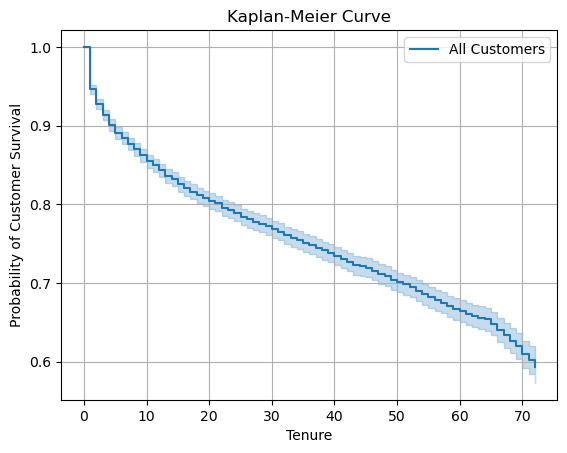

In [7]:
#Create a KaplanMeier object, imported from lifelines
kmf = KaplanMeierFitter()
#Calculate the K-M curve for all groups
kmf.fit(df_time,event_observed = df_event,label = "All Customers")
#Plot the curve and assign labels
kmf.plot()
plt.ylabel('Probability of Customer Survival')
plt.xlabel('Tenure')
plt.grid()
plt.title('Kaplan-Meier Curve')


## Log-Rank Test for Comparing Survival Curves  

We can use the **non-parametric log-rank test** to compare survival curves between different groups.  

- **Assumption**: The hazards of the groups are proportional.  
- **Null Hypothesis ($H_0$)**: The probability of experiencing the event is the same across groups at all time points.  

---

### Test Statistic  

The log-rank test compares the **observed** and **expected** number of events in each group.  
For group $j$, the log-rank statistic is:  

$$
k_{j} = \frac{(O_{j}-E_{j})^{2}}{var(O_{j}-E_{j})}
$$  

where:  
- $O_j$ = observed number of events in group $j$,  
- $E_j$ = expected number of events in group $j$.  

The difference between observed and expected events is:  

$$
O_{j}-E_{j} = \sum_{i}(o_{ij}-e_{ij})
$$  

The variance is:  

$$
var(O_{j}-E_{j}) = o_{i}\frac{n_{ij}}{n_{i}}\Big(1-\frac{n_{ij}}{n_{i}}\Big)\frac{(n_{i}-o_{i})}{(n_{i}-1)}
$$  

where:  
- $o_{ij}$ = observed number of events in group $j$ at time $i$,  
- $e_{ij} = \frac{n_{ij}}{n_i}o_{i}$ = expected number of events in group $j$ at time $i$,  
- $n_{ij}$ = number at risk in group $j$ at time $i$,  
- $n_{i}$ = number at risk across all groups at time $i$,  
- $o_i$ = observed number of events across all groups at time $i$.  

---

### Multiple Groups  

When comparing multiple groups ($k$):  

- Compute the log-rank test scores between each of the $k-1$ groups.  
- Write them as a vector of log-rank statistics:  

$$
\mathbf{Z} = (k_1, k_2, \dots, k_{k-1})
$$  

Note: The sum of log-rank statistics is zero ($\sum k_j = 0$), so one can be omitted.  

The **overall test statistic** is:  

$$
logrankstatistic = \mathbf{Z} \, \Sigma^{-1} \, \mathbf{Z}'
$$  

which follows a $\chi^2$ distribution, where:  
- $\Sigma$ is the $(k-1) \times (k-1)$ variance-covariance matrix of $\mathbf{Z}$.  
- Diagonal elements = variances ($k_j$),  
- Off-diagonal elements = covariances.  

The covariance between groups $j$ and $g$ is:  

$$
covar(k_{jg}) = o_{i}\frac{(n_{ij}n_{ig})}{(n_{i}n_{i})}\frac{(n_{i}-o_{i})}{(n_{i}-1)}
$$  

---

### Interpretation  

- **Rejecting $H_0$** means the survival times across groups do not come from the same distribution.  
- However, it does not indicate **which group** differs; only that at least one group is different.  
- A statistically significant log-rank test statistic suggests differences in survival curves.  


## Gender

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.53 0.47      1.09

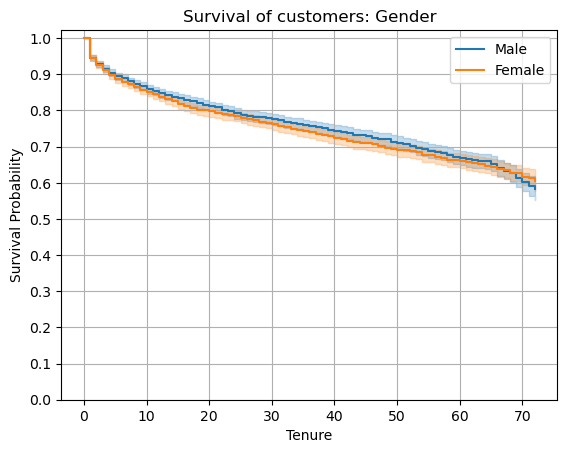

In [8]:
male = (survival_data['gender_Male'] == 1)
female = (survival_data['gender_Male'] == 0)

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(df_time[male],event_observed = df_event[male],label = "Male")
plot1 = kmf.plot(ax = ax)

kmf.fit(df_time[female],event_observed = df_event[female],label = "Female")
plot2 = kmf.plot(ax = plot1)
                 
plt.title('Survival of customers: Gender')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
plt.grid()
groups = logrank_test(df_time[male], df_time[female], event_observed_A=df_event[male], event_observed_B=df_event[female])
groups.print_summary()

## Senior Citizen

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
         109.49 <0.005     82.71

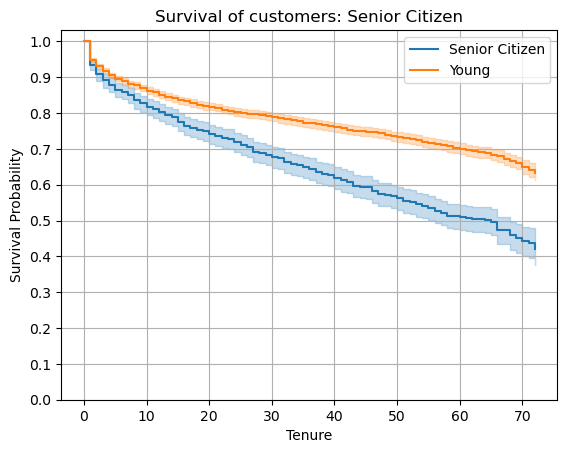

In [9]:
SeniorCitizen = (survival_data['SeniorCitizen_1'] == 1)
Young = (survival_data['SeniorCitizen_1'] == 0)

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(df_time[SeniorCitizen],event_observed = df_event[SeniorCitizen],label = "Senior Citizen")
plot1 = kmf.plot(ax = ax)

kmf.fit(df_time[Young],event_observed = df_event[Young],label = "Young")
plot2 = kmf.plot(ax = plot1)
                 
plt.title('Survival of customers: Senior Citizen')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
plt.grid()
groups = logrank_test(df_time[SeniorCitizen], df_time[Young], event_observed_A=df_event[SeniorCitizen], event_observed_B=df_event[Young])
groups.print_summary()

## Partner

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.53 0.47      1.09

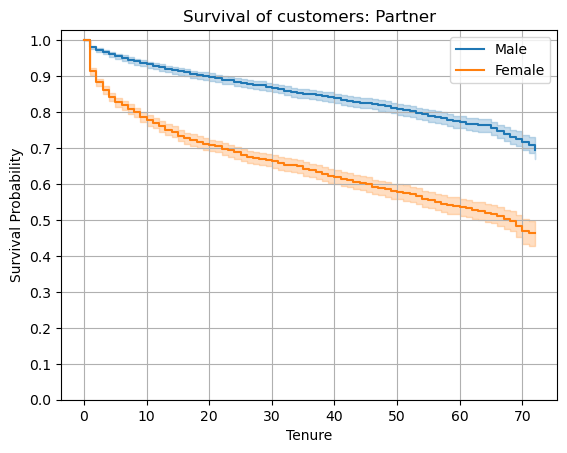

In [10]:
Partner = (survival_data['Partner_Yes'] == 1)
Single = (survival_data['Partner_Yes'] == 0)

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(df_time[Partner],event_observed = df_event[Partner],label = "Male")
plot1 = kmf.plot(ax = ax)

kmf.fit(df_time[Single],event_observed = df_event[Single],label = "Female")
plot2 = kmf.plot(ax = plot1)
                 
plt.title('Survival of customers: Partner')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
plt.grid()
groups = logrank_test(df_time[male], df_time[female], event_observed_A=df_event[male], event_observed_B=df_event[female])
groups.print_summary()

## Dependents

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
         232.70 <0.005    172.12

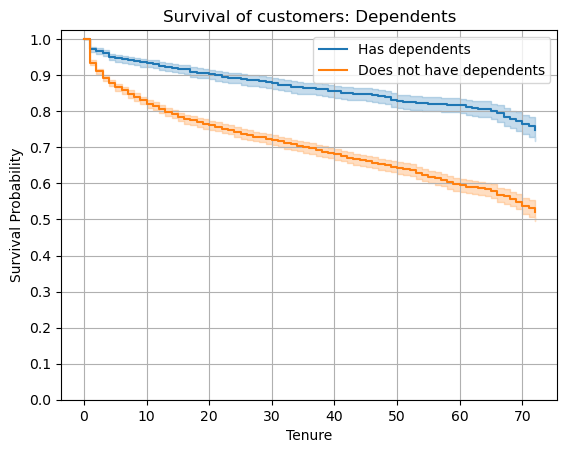

In [11]:
Dependents = (survival_data['Dependents_Yes'] == 1)
no_Dependents = (survival_data['Dependents_Yes'] == 0)

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(df_time[Dependents],event_observed = df_event[Dependents],label = "Has dependents")
plot1 = kmf.plot(ax = ax)

kmf.fit(df_time[no_Dependents],event_observed = df_event[no_Dependents],label = "Does not have dependents")
plot2 = kmf.plot(ax = plot1)
                 
plt.title('Survival of customers: Dependents')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.grid()
plt.yticks(np.linspace(0,1,11))
groups = logrank_test(df_time[Dependents], df_time[no_Dependents], event_observed_A=df_event[Dependents], event_observed_B=df_event[no_Dependents])
groups.print_summary()


## Payment Method

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 3
             alpha = 0.95
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
         865.24 <0.005    619.58

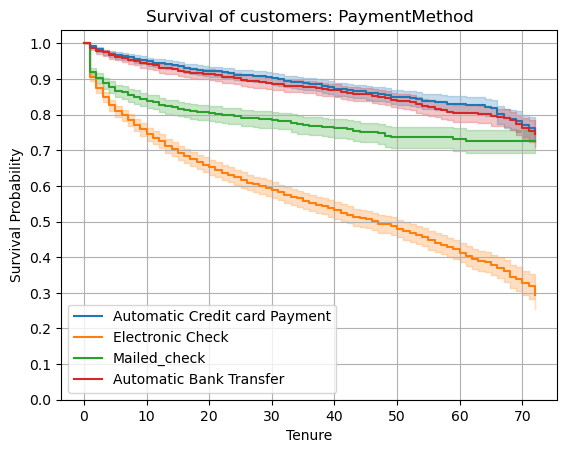

In [12]:
Credit_Card = (survival_data['PaymentMethod_Credit card (automatic)'] == 1)
electronic_check = (survival_data['PaymentMethod_Electronic check'] == 1)
mailed_check = (survival_data['PaymentMethod_Mailed check'] == 1)
automatic_Bank_Transfer = ((survival_data['PaymentMethod_Credit card (automatic)'] == 0) & (survival_data['PaymentMethod_Electronic check'] == 0) & (survival_data['PaymentMethod_Mailed check'] == 0))

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(df_time[Credit_Card],event_observed = df_event[Credit_Card],label = "Automatic Credit card Payment")
plot1 = kmf.plot(ax = ax)

kmf.fit(df_time[electronic_check],event_observed = df_event[electronic_check],label = "Electronic Check")
plot2 = kmf.plot(ax = plot1)

kmf.fit(df_time[mailed_check],event_observed = df_event[mailed_check],label = "Mailed_check")
plot3 = kmf.plot(ax = plot2)

kmf.fit(df_time[automatic_Bank_Transfer],event_observed = df_event[automatic_Bank_Transfer],label = "Automatic Bank Transfer")
plot4 = kmf.plot(ax = plot3)
                 
plt.title('Survival of customers: PaymentMethod')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
plt.grid()
twoplusgroups_logrank = multivariate_logrank_test(data['tenure'], data['PaymentMethod'], data['Churn'], alpha = 0.95)
twoplusgroups_logrank.print_summary()


## Phone Service

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.43 0.51      0.97

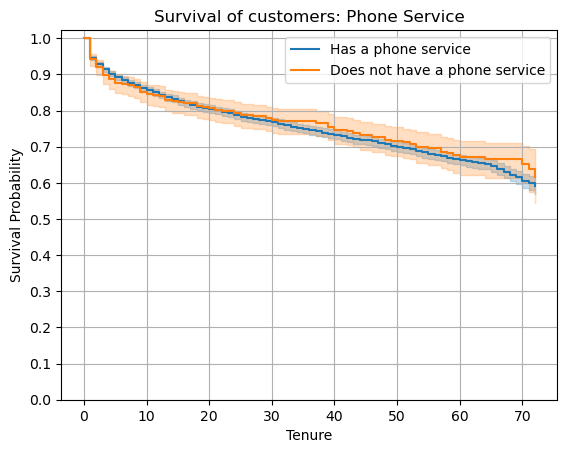

In [13]:
PhoneService = (survival_data['PhoneService_Yes'] == 1)
no_PhoneService = (survival_data['PhoneService_Yes'] == 0)

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(df_time[PhoneService],event_observed = df_event[PhoneService],label = "Has a phone service")
plot1 = kmf.plot(ax = ax)

kmf.fit(df_time[no_PhoneService],event_observed = df_event[no_PhoneService],label = "Does not have a phone service")
plot2 = kmf.plot(ax = plot1)
                 
plt.title('Survival of customers: Phone Service')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
plt.grid()
groups = logrank_test(df_time[PhoneService], df_time[no_PhoneService], event_observed_A=df_event[PhoneService], event_observed_B=df_event[no_PhoneService])
groups.print_summary()

## Paperless Billing

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
         189.51 <0.005    140.82

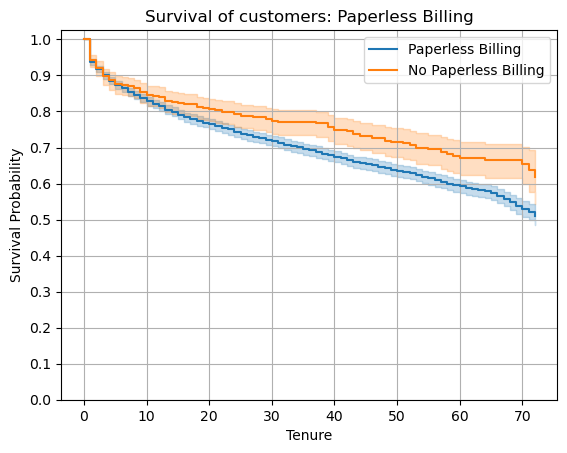

In [14]:
PaperlessBilling = (survival_data['PaperlessBilling_Yes'] == 1)
no_PaperlessBilling = (survival_data['PaperlessBilling_Yes'] == 0)

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(df_time[PaperlessBilling],event_observed = df_event[PaperlessBilling],label = "Paperless Billing")
plot1 = kmf.plot(ax = ax)

kmf.fit(df_time[no_PhoneService],event_observed = df_event[no_PhoneService],label = "No Paperless Billing")
plot2 = kmf.plot(ax = plot1)
                 
plt.title('Survival of customers: Paperless Billing')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.grid()
plt.yticks(np.linspace(0,1,11))
groups = logrank_test(df_time[PaperlessBilling], df_time[no_PaperlessBilling], event_observed_A=df_event[PaperlessBilling], event_observed_B=df_event[no_PaperlessBilling])
groups.print_summary()

## Multiple Lines

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
             alpha = 0.95
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          30.97 <0.005     22.34

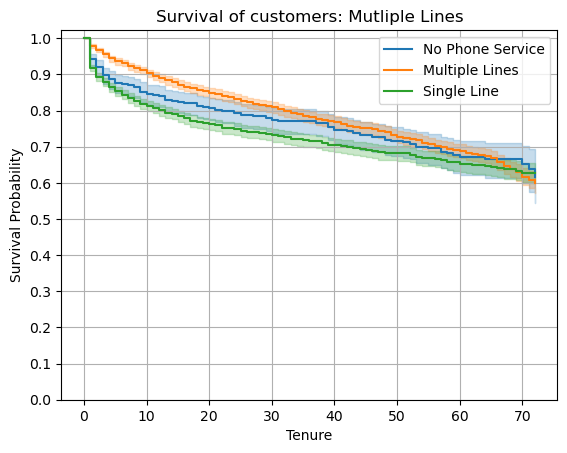

In [15]:
no_phone = (survival_data['MultipleLines_No phone service'] == 1)
multiLines = (survival_data['MultipleLines_Yes'] == 1)
no_multiLines = ((survival_data['MultipleLines_Yes'] == 0) & (survival_data['MultipleLines_No phone service'] == 0))

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(df_time[no_phone],event_observed = df_event[no_phone],label = "No Phone Service")
plot1 = kmf.plot(ax = ax)

kmf.fit(df_time[multiLines],event_observed = df_event[multiLines],label = "Multiple Lines")
plot2 = kmf.plot(ax = plot1)

kmf.fit(df_time[no_multiLines],event_observed = df_event[no_multiLines],label = "Single Line")
plot3 = kmf.plot(ax = plot2)
                 
plt.title('Survival of customers: Mutliple Lines')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.grid()
plt.yticks(np.linspace(0,1,11))
twoplusgroups_logrank = multivariate_logrank_test(data['tenure'], data['MultipleLines'], data['Churn'], alpha = 0.95)
twoplusgroups_logrank.print_summary()

## Internet Service

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
             alpha = 0.95
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
         520.12 <0.005    375.19

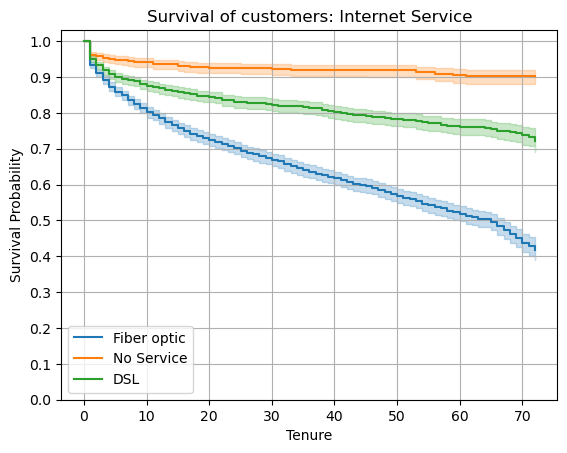

In [16]:
Fiber_optic = (survival_data['InternetService_Fiber optic'] == 1)
No_Service = (survival_data['InternetService_No'] == 1)
DSL = ((survival_data['InternetService_Fiber optic'] == 0) & (survival_data['InternetService_No'] == 0))

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(df_time[Fiber_optic],event_observed = df_event[Fiber_optic],label = "Fiber optic")
plot1 = kmf.plot(ax = ax)

kmf.fit(df_time[No_Service],event_observed = df_event[No_Service],label = "No Service")
plot2 = kmf.plot(ax = plot1)

kmf.fit(df_time[DSL],event_observed = df_event[DSL],label = "DSL")
plot3 = kmf.plot(ax = plot2)
                 
plt.title('Survival of customers: Internet Service')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
plt.grid()
twoplusgroups_logrank = multivariate_logrank_test(data['tenure'], data['InternetService'], data['Churn'], alpha = 0.95)
twoplusgroups_logrank.print_summary()

## Contact

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
             alpha = 0.95
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
        2352.87 <0.005       inf

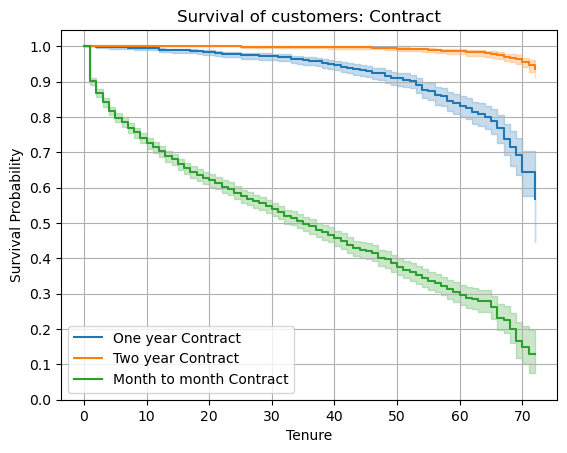

In [17]:
Contract_One_year = (survival_data['Contract_One year'] == 1)
Contract_Two_year = (survival_data['Contract_Two year'] == 1)
Contract_month_to_month = ((survival_data['Contract_One year'] == 0) & (survival_data['Contract_Two year'] == 0))

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(df_time[Contract_One_year],event_observed = df_event[Contract_One_year],label = "One year Contract")
plot1 = kmf.plot(ax = ax)

kmf.fit(df_time[Contract_Two_year],event_observed = df_event[Contract_Two_year],label = "Two year Contract")
plot2 = kmf.plot(ax = plot1)

kmf.fit(df_time[Contract_month_to_month],event_observed = df_event[Contract_month_to_month],label = "Month to month Contract")
plot3 = kmf.plot(ax = plot2)
                 
plt.title('Survival of customers: Contract')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
plt.grid()
twoplusgroups_logrank = multivariate_logrank_test(data['tenure'], data['Contract'], data['Churn'], alpha = 0.95)
twoplusgroups_logrank.print_summary()

## Streaming Movies

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
             alpha = 0.95
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
         378.43 <0.005    272.98

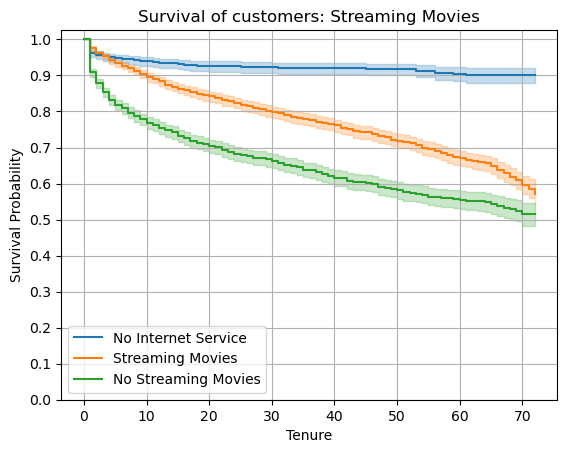

In [18]:
no_internetService = (survival_data['StreamingMovies_No internet service'] == 1)
StreamingMovies = (survival_data['StreamingMovies_Yes'] == 1)
no_StreamingMovies = ((survival_data['StreamingMovies_No internet service'] == 0) & (survival_data['StreamingMovies_Yes'] == 0))

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(df_time[no_internetService],event_observed = df_event[no_internetService],label = "No Internet Service")
plot1 = kmf.plot(ax = ax)

kmf.fit(df_time[StreamingMovies],event_observed = df_event[StreamingMovies],label = "Streaming Movies")
plot2 = kmf.plot(ax = plot1)

kmf.fit(df_time[no_StreamingMovies],event_observed = df_event[no_StreamingMovies],label = "No Streaming Movies")
plot3 = kmf.plot(ax = plot2)
                 
plt.title('Survival of customers: Streaming Movies')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
plt.grid()
twoplusgroups_logrank = multivariate_logrank_test(data['tenure'], data['StreamingMovies'], data['Churn'], alpha = 0.95)
twoplusgroups_logrank.print_summary()

## Streaming TV

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
             alpha = 0.95
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
         368.31 <0.005    265.68

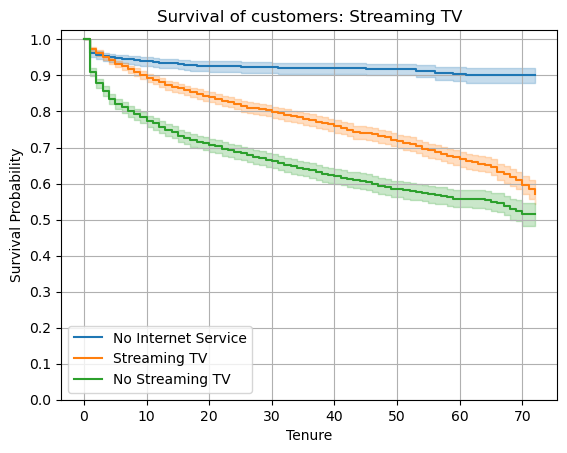

In [19]:
no_internetService = (survival_data['StreamingTV_No internet service'] == 1)
StreamingTV = (survival_data['StreamingTV_Yes'] == 1)
no_StreamingTV = ((survival_data['StreamingTV_No internet service'] == 0) & (survival_data['StreamingTV_Yes'] == 0))

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(df_time[no_internetService],event_observed = df_event[no_internetService],label = "No Internet Service")
plot1 = kmf.plot(ax = ax)

kmf.fit(df_time[StreamingTV],event_observed = df_event[StreamingTV],label = "Streaming TV")
plot2 = kmf.plot(ax = plot1)

kmf.fit(df_time[no_StreamingTV],event_observed = df_event[no_StreamingTV],label = "No Streaming TV")
plot3 = kmf.plot(ax = plot2)
                 
plt.title('Survival of customers: Streaming TV')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
plt.grid()
twoplusgroups_logrank = multivariate_logrank_test(data['tenure'], data['StreamingTV'], data['Churn'], alpha = 0.95)
twoplusgroups_logrank.print_summary()

## Tech Support

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
             alpha = 0.95
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
         989.56 <0.005    713.82

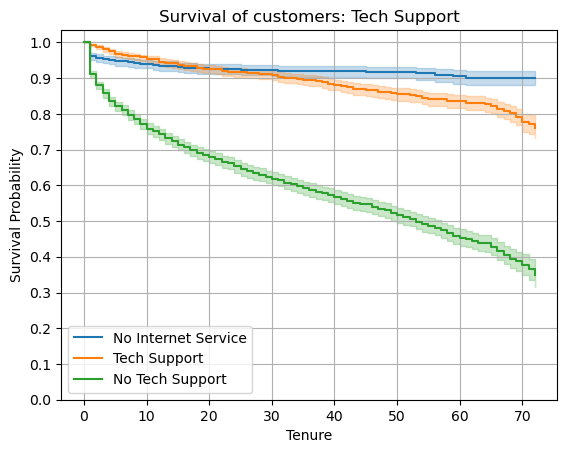

In [20]:
no_internetService = (survival_data['TechSupport_No internet service'] == 1)
TechSupport = (survival_data['TechSupport_Yes'] == 1)
no_TechSupport = ((survival_data['TechSupport_No internet service'] == 0) & (survival_data['TechSupport_Yes'] == 0))

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(df_time[no_internetService],event_observed = df_event[no_internetService],label = "No Internet Service")
plot1 = kmf.plot(ax = ax)

kmf.fit(df_time[TechSupport],event_observed = df_event[TechSupport],label = "Tech Support")
plot2 = kmf.plot(ax = plot1)

kmf.fit(df_time[no_TechSupport],event_observed = df_event[no_TechSupport],label = "No Tech Support")
plot3 = kmf.plot(ax = plot2)
                 
plt.title('Survival of customers: Tech Support')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
plt.grid()
twoplusgroups_logrank = multivariate_logrank_test(data['tenure'], data['TechSupport'], data['Churn'], alpha = 0.95)
twoplusgroups_logrank.print_summary()

## Device Protection

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
             alpha = 0.95
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
         763.51 <0.005    550.75

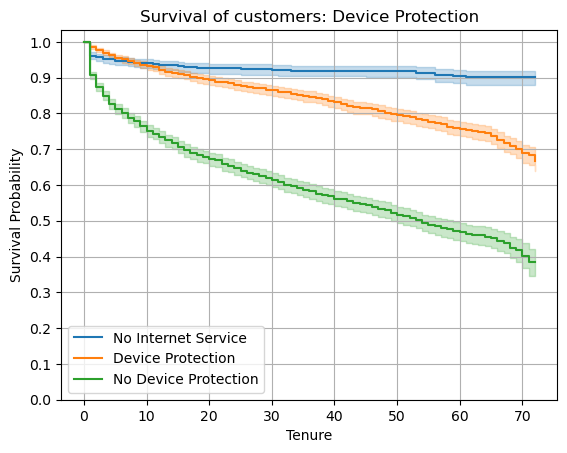

In [21]:
no_internetService = (survival_data['DeviceProtection_No internet service'] == 1)
DeviceProtection = (survival_data['DeviceProtection_Yes'] == 1)
no_DeviceProtection = ((survival_data['DeviceProtection_No internet service'] == 0) & (survival_data['DeviceProtection_Yes'] == 0))

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(df_time[no_internetService],event_observed = df_event[no_internetService],label = "No Internet Service")
plot1 = kmf.plot(ax = ax)

kmf.fit(df_time[DeviceProtection],event_observed = df_event[DeviceProtection],label = "Device Protection")
plot2 = kmf.plot(ax = plot1)

kmf.fit(df_time[no_DeviceProtection],event_observed = df_event[no_DeviceProtection],label = "No Device Protection")
plot3 = kmf.plot(ax = plot2)
                 
plt.title('Survival of customers: Device Protection')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
plt.grid()
twoplusgroups_logrank = multivariate_logrank_test(data['tenure'], data['DeviceProtection'], data['Churn'], alpha = 0.95)
twoplusgroups_logrank.print_summary()

## Online Security

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
             alpha = 0.95
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
        1013.86 <0.005    731.35

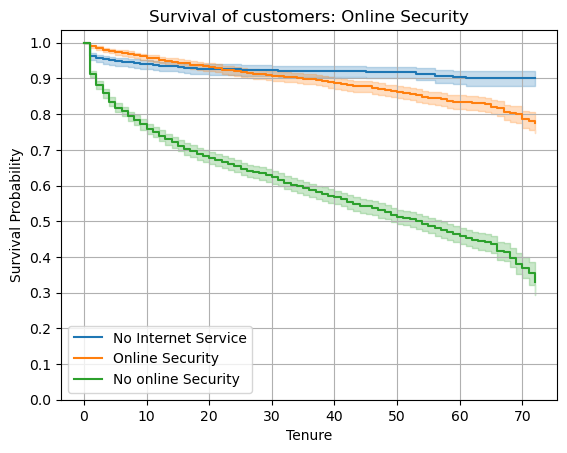

In [22]:
no_internetService = (survival_data['OnlineSecurity_No internet service'] == 1)
onlineSecurity = (survival_data['OnlineSecurity_Yes'] == 1)
no_onlineSecurity = ((survival_data['OnlineSecurity_No internet service'] == 0) & (survival_data['OnlineSecurity_Yes'] == 0))

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(df_time[no_internetService],event_observed = df_event[no_internetService],label = "No Internet Service")
plot1 = kmf.plot(ax = ax)

kmf.fit(df_time[onlineSecurity],event_observed = df_event[onlineSecurity],label = "Online Security")
plot2 = kmf.plot(ax = plot1)

kmf.fit(df_time[no_onlineSecurity],event_observed = df_event[no_onlineSecurity],label = "No online Security")
plot3 = kmf.plot(ax = plot2)
                 
plt.title('Survival of customers: Online Security')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
plt.grid()
twoplusgroups_logrank = multivariate_logrank_test(data['tenure'], data['OnlineSecurity'], data['Churn'], alpha = 0.95)
twoplusgroups_logrank.print_summary()